# 09A - Recurrent Neural Networks for Time Series

## 0. Setup

The setup below includes code for both TensorFlow and PyTorch.

`pip install scikit-learn`  
`python3 -m pip install -U scikit-learn --user`

`pip install tensorflow`  
`python3 -m pip install -U tensorflow --user`

`pip install torch`  
`python3 -m pip install -U torch --user`

`pip install transformers`  
`python3 -m pip install -U transformers --user`

In [5]:
# Common imports
import numpy as np
import os
# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.11 from "C:\Users\giselara\anaconda3\python.exe"
  * The NumPy version is: "1.24.3"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: _multiarray_umath failed to import

ImportError: numpy._core.umath failed to import

## 0. Setup - PyTorch check

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from collections import Counter

# Check if Metal Performance Shaders is available - on macOS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Metal Performance Shaders) device.")
    
# Check for CUDA (NVIDIA GPU)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Device Properties: {torch.cuda.get_device_properties(0)}")
    
# Default to CPU if no accelerators are available
else:
    device = torch.device("cpu")
    print("Using CPU device.")

# Display summary of available devices
print(f"Selected device: {device}")
print("Available devices summary:")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"MPS Available: {torch.backends.mps.is_available()}")

Using MPS (Metal Performance Shaders) device.
Selected device: mps
Available devices summary:
CUDA Available: False
MPS Available: True


## 0. TensorFlow check

In [7]:
# Python ≥3.8 is required
import sys
assert sys.version_info >= (3, 8)

# Scikit-Learn ≥1.0 is required
import sklearn
assert sklearn.__version__ >= "1.0"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.test.is_gpu_available():
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "rnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.11 from "C:\Users\giselara\anaconda3\python.exe"
  * The NumPy version is: "1.24.3"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: _multiarray_umath failed to import

ImportError: numpy._core.umath failed to import

## Basic RNNs

### Generate the Dataset

* The function below generates as many time series as specified in `batch_size`, each of length `n_steps`. 

* All series are univariate, i.e. only one value is produced per time step in each series. 

* The function returns a NumPy array of shape `[batch size, time steps, 1]`. 

* Each series is the addition of two sine waves of fixed amplitudes but random frequency, plus somenoise.

In [10]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [11]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [12]:
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

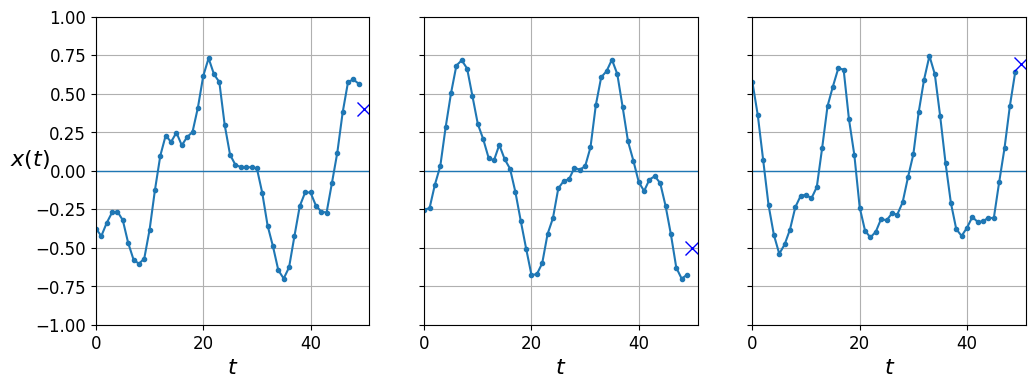

In [13]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))
plt.show()

### 2. Try some predictors

### 2.1 Naive predictions 
We just predict the last observed value.

In [15]:
y_pred = X_valid[:, -1] # last observed value
np.mean(keras.losses.MSE(y_valid, y_pred)) ##mean_squared_error(y_valid, y_pred))

0.020211367

### blue cross = forecast
### red dot = actual

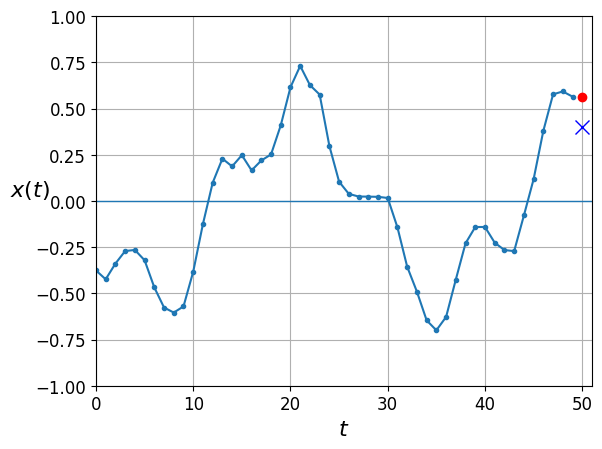

In [16]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

### 2.2 Linear Prediction - Perceptron (TF)

In [17]:
np.random.seed(42)
tf.random.set_seed(42)

n_net = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

n_net.compile(
    loss="mse", 
    optimizer="adam", 
    metrics=[keras.metrics.RootMeanSquaredError()]
)
history = n_net.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20


/Users/nick/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1083 - root_mean_squared_error: 0.3256 - val_loss: 0.0359 - val_root_mean_squared_error: 0.1895
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - loss: 0.0302 - root_mean_squared_error: 0.1736 - val_loss: 0.0222 - val_root_mean_squared_error: 0.1491
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - loss: 0.0198 - root_mean_squared_error: 0.1406 - val_loss: 0.0171 - val_root_mean_squared_error: 0.1308
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - loss: 0.0154 - root_mean_squared_error: 0.1242 - val_loss: 0.0142 - val_root_mean_squared_error: 0.1193
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 0.0129 - root_mean_squared_error: 0.1137 - val_loss: 0.0121 - val_root_mean_squared_error: 0.1102
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - loss: 0.0111 - root_mean_squared_error: 0.1052 - val_loss: 0.0104 - val_root_mean_squared_error: 0.1021
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step

In [18]:
mse, rmse = n_net.evaluate(X_valid, y_valid, verbose=0)
mse, rmse

(0.00401582196354866, 0.06337051093578339)

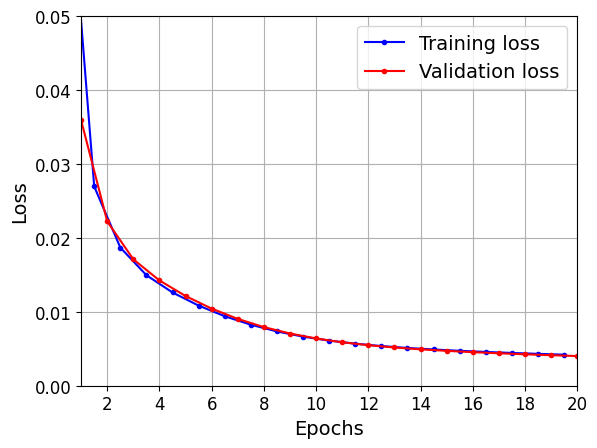

In [19]:
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

It looks  as if the system has been trained nicely. Let's see the predictions.

### blue cross = forecast
### red dot = actual

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step


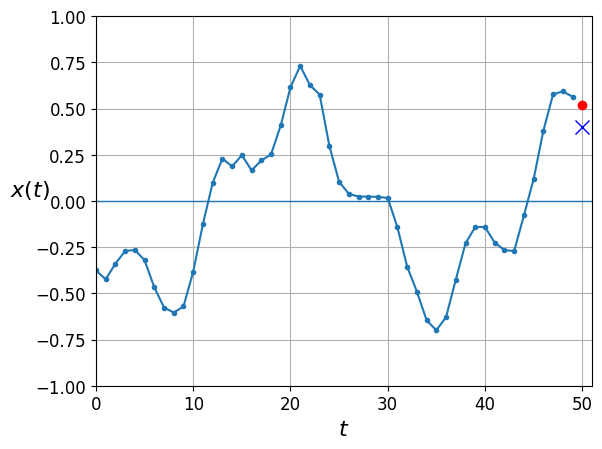

In [20]:
y_pred = n_net.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

### 2.3 A Simple RNN (TF)

* This is really the simplest conceivable RNN. 

* There is no need to specify the length of the input sequences here as an RNN can process any number of time points (hence the first input dimension is set to `None`). 

* By default, the SimpleRNN layer uses the $tanh()$ activation functionn

#### TensorFlow Code:

In [22]:
np.random.seed(42)
tf.random.set_seed(42)

n_net = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005) # lr=0.005
n_net.compile(loss=keras.metrics.MSE, ##.mean_squared_error, 
              optimizer=optimizer, 
              metrics=[keras.metrics.RootMeanSquaredError()])
history = n_net.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8557 - root_mean_squared_error: 0.9232 - val_loss: 0.3388 - val_root_mean_squared_error: 0.5821
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2708 - root_mean_squared_error: 0.5191 - val_loss: 0.1475 - val_root_mean_squared_error: 0.3840
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1488 - root_mean_squared_error: 0.3858 - val_loss: 0.1491 - val_root_mean_squared_error: 0.3861
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1468 - root_mean_squared_error: 0.3832 - val_loss: 0.1503 - val_root_mean_squared_error: 0.3877
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1460 - root_mean_squared_error: 0.3821 - val_loss: 0.1515 - val_root_mean_squared_error: 0.3892
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1312 - root_mean_squared_error: 0.3619 - val_loss: 0.0686 - val_root_mean_squared_error: 0.2619
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

In [23]:
mse, rmse = n_net.evaluate(X_valid, y_valid, verbose=0)
mse, rmse

(0.01115200761705637, 0.10560306906700134)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


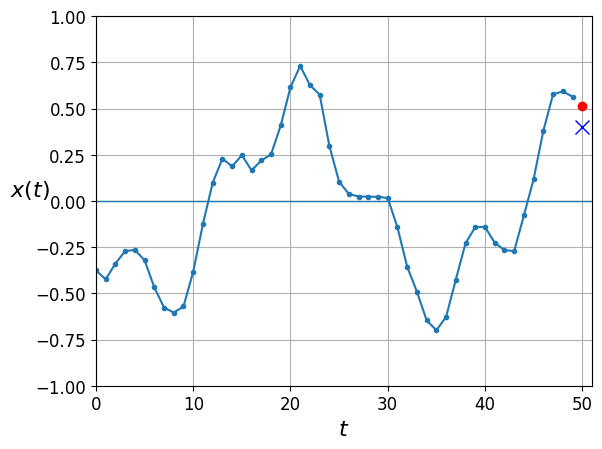

In [24]:
y_pred = n_net.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

This is better than the naive approach but not as good as the linear Perceptron model. However, not that for each neuron, a linear model has one parameter per input (i.e. per time step), plus a bias term (in our case, that was 51 parameters, but in general it would be $N_{time\_steps} + 1$). Coversely, for each recurrent neuron in the simple RNN, there’s 1 parameter per input and 1 per hidden state dimension  plus a bias term. In this  simple RNN there is just a neuron, hence 1 hidden state dimension: that’s a total of 3 parameters. That scales much better, for time series with thousands or millions of time points.



### 2.3 A Simple RNN (PyTorch)

* Instead of `Sequential`, PyTorch typically uses class-based model definitions inheriting from `nn.Module`

* PyTorch's `nn.RNN` requires explicit specification of `input_size` and `hidden_size`

* We set `batch_first=True` to match Keras's input format `(batch_size, time_steps, features)`

* The forward method needs to handle the hidden state returned by PyTorch's RNN

#### PyTorch Code:

In [43]:
np.random.seed(42)
torch.manual_seed(42)

class SimpleRNNModel(nn.Module):
    def __init__(self):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=1, # input_size=1 (single feature input)
            hidden_size=1, # hidden_size=1 (matches the RNN units in Keras)
            num_layers=1, # num_layers=1 (single RNN layer)
            batch_first=True # batch_first=True (to match Keras sequence input format)
        )
    
    def forward(self, x):
        output, _ = self.rnn(x)
        return output[:, -1, :]

# Model initialization
model = SimpleRNNModel()

# Optimizer (equivalent to Keras Adam with lr=0.005)
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Loss function (MSE for training, RMSE for metrics)
criterion = nn.MSELoss()


In [44]:
# Convert data to PyTorch tensors (assuming X_train, y_train, X_valid, y_valid are numpy arrays)
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_valid_tensor = torch.FloatTensor(X_valid)
y_valid_tensor = torch.FloatTensor(y_valid)

# Create dataset and dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [48]:
# Training loop
n_epochs = 20
train_losses = []
valid_losses = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    
    # Training
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss = train_loss / len(train_loader)
    
    # Validation
    model.eval()
    with torch.no_grad():
        valid_outputs = model(X_valid_tensor)
        valid_loss = criterion(valid_outputs, y_valid_tensor)
        # Calculate RMSE for validation
        valid_rmse = torch.sqrt(valid_loss)
    
    train_losses.append(train_loss)
    valid_losses.append(valid_rmse.item())
    
    print(f'Epoch {epoch+1}/{n_epochs}', f'Training loss: {train_loss:.4f}', f'Validation RMSE: {valid_rmse:.4f}')

Epoch 1/20 Training loss: 0.0115 Validation RMSE: 0.1041
Epoch 2/20 Training loss: 0.0114 Validation RMSE: 0.1045
Epoch 3/20 Training loss: 0.0114 Validation RMSE: 0.1050
Epoch 4/20 Training loss: 0.0114 Validation RMSE: 0.1049
Epoch 5/20 Training loss: 0.0114 Validation RMSE: 0.1047
Epoch 6/20 Training loss: 0.0114 Validation RMSE: 0.1042
Epoch 7/20 Training loss: 0.0114 Validation RMSE: 0.1052
Epoch 8/20 Training loss: 0.0114 Validation RMSE: 0.1045
Epoch 9/20 Training loss: 0.0114 Validation RMSE: 0.1045
Epoch 10/20 Training loss: 0.0114 Validation RMSE: 0.1046
Epoch 11/20 Training loss: 0.0115 Validation RMSE: 0.1043
Epoch 12/20 Training loss: 0.0114 Validation RMSE: 0.1055
Epoch 13/20 Training loss: 0.0114 Validation RMSE: 0.1080
Epoch 14/20 Training loss: 0.0115 Validation RMSE: 0.1047
Epoch 15/20 Training loss: 0.0115 Validation RMSE: 0.1042
Epoch 16/20 Training loss: 0.0114 Validation RMSE: 0.1044
Epoch 17/20 Training loss: 0.0114 Validation RMSE: 0.1051
Epoch 18/20 Training lo

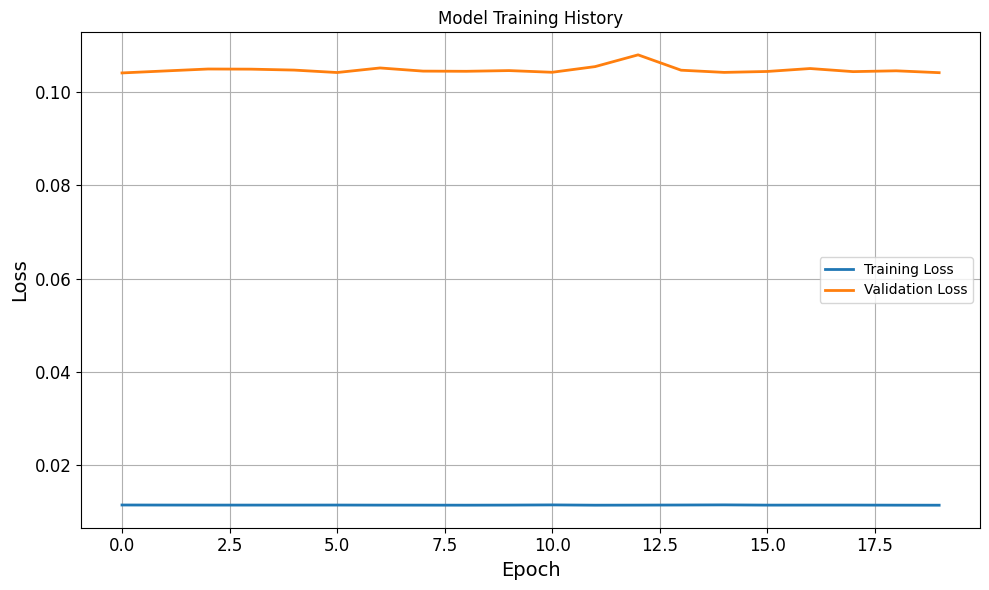

In [50]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, valid_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', linewidth=2)
    plt.plot(valid_losses, label='Validation Loss', linewidth=2)
    plt.title('Model Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Use the function to plot the losses we collected during training
plot_training_history(train_losses, valid_losses)

### Question: What's going on here? Why is the training performance not in alignment with the validation performance?

In [51]:
model.eval()

# Convert input data to tensor if it's not already
X_valid_tensor = torch.FloatTensor(X_valid)

# Make predictions without computing gradients
with torch.no_grad():
    predictions = model(X_valid_tensor)

# Convert predictions to numpy array if needed
predictions_np = predictions.numpy()

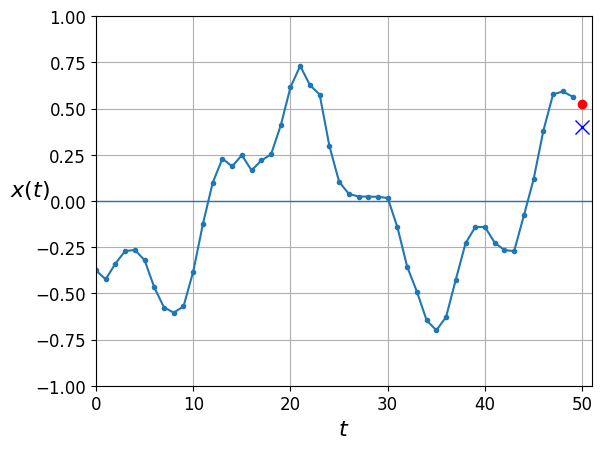

In [52]:
y_pred = predictions_np
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

### 2.4 Deep RNNs

### **Exercise 01:** create a neural network with 3 recurrent layers:
* two layers of 20 recurrent units each
* one output layer with the appropriate number of recurrent neurons

Compile the network setting the appropriate loss function, the Adam optimizer, and RMSE ad an additional metric. Then train the network for the same number of epochs as the previous models.

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 22s 3ms/sample - loss: 0.0531 - root_mean_squared_error: 0.2304 - val_loss: 0.0083 - val_root_mean_squared_error: 0.0911
Epoch 2/20
7000/7000 [==============================] - 19s 3ms/sample - loss: 0.0074 - root_mean_squared_error: 0.0862 - val_loss: 0.0055 - val_root_mean_squared_error: 0.0739
Epoch 3/20
7000/7000 [==============================] - 20s 3ms/sample - loss: 0.0054 - root_mean_squared_error: 0.0738 - val_loss: 0.0050 - val_root_mean_squared_error: 0.0704
Epoch 4/20
7000/7000 [==============================] - 21s 3ms/sample - loss: 0.0047 - root_mean_squared_error: 0.0686 - val_loss: 0.0041 - val_root_mean_squared_error: 0.0637
Epoch 5/20
7000/7000 [==============================] - 21s 3ms/sample - loss: 0.0044 - root_mean_squared_error: 0.0660 - val_loss: 0.0041 - val_root_mean_squared_error: 0.0642
Epoch 6/20
7000/7000 [==============================] - 20s 3ms/sam

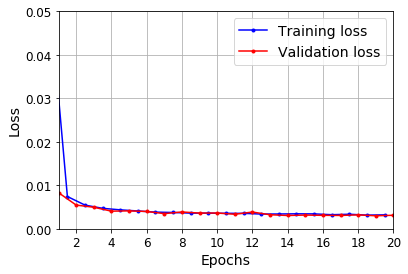

In [24]:
plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

### blue cross = forecast
### red dot = actual

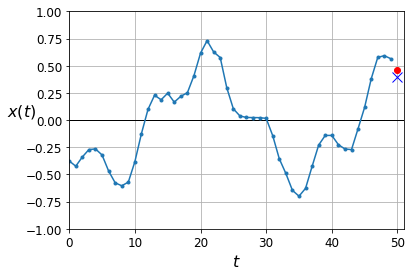

In [25]:
y_pred = n_net.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

## 3. Forecasting Several Steps Ahead

Until now we have only predicted the value at the next time step. Using the same network(s) we could have predicted values _n_ steps ahead just by changing the targets appropriately (e.g., to predict 10 steps ahead, change the targets to be the value 10 steps ahead instead of 1 step ahead). But what can we do if our goal is to predict the next _n_ values? There are basically two options here.

 1) use the model we already trained, make it predict the next value, then add that value to the inputs (acting as if this predicted value had actually occurred), and use the network again to predict the following value, and go on like this:

In [26]:
np.random.seed(43) # not 42, as it would give the first series in the train set

series = generate_time_series(1, n_steps + 10)
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new
for step_ahead in range(10):
    y_pred_one = n_net.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]

In [27]:
Y_pred.shape

(1, 10, 1)

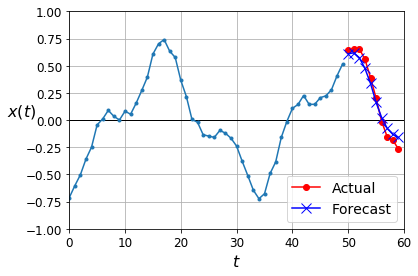

In [29]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

2) Train an RNN to predict all 10 next values at once. It is still possible to use a sequence-to-vector model, but this will produce 10 values instead of 1. For it to work we need to modify the targets to be vectors containing the next 10 values:

In [34]:
series = generate_time_series(10000, n_steps + 10)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]

Now we need the output layer to have 10 units rather than 1:

In [35]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

### **Exercise 02:** Compile and train the network defined above. Evaluate its performance